# Modelos Supervisados — Detección de Fraude

**Auditoría técnica — CONFAMA**

Con el dataset limpio en mano, el siguiente paso es entrenar clasificadores que puedan separar fraude de operaciones legítimas. El desafío principal aquí no es el algoritmo sino la forma en que manejamos el desbalance (≈1.5% de fraude) y cómo evitamos que las métricas nos engañen.

La elección de Random Forest + XGBoost no es arbitraria: ambos son robustos a variables en escalas distintas, manejan bien interacciones no lineales y ofrecen mecanismos nativos para ajustar el costo de cada error. Además, SHAP funciona directamente con estos modelos sin aproximaciones costosas.

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.facecolor': '#0F172A', 'axes.facecolor': '#1E293B',
    'axes.edgecolor': '#334155',   'axes.labelcolor': '#94A3B8',
    'xtick.color': '#94A3B8',      'ytick.color': '#94A3B8',
    'text.color': '#F1F5F9',       'grid.color': '#1E293B',
})
ROJO = '#EF4444'; VERDE = '#22C55E'; AZUL = '#3B82F6'; AMBER = '#F59E0B'
print('✅ Dependencias listas')

✅ Dependencias listas


## Carga de datos preprocesados

Partimos del CSV que generó el notebook anterior, ya con las features construidas y los nulos imputados. No repetimos la limpieza aquí para mantener los notebooks modulares y auditable cada etapa por separado.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/df_preprocesado.csv')

## 1. Construcción de la matriz de features

No usamos todas las columnas del dataset. Excluimos identificadores (`id_transaccion`), el target mismo y variables que causarían data leakage si se incluyeran en el modelo.

Las variables seleccionadas capturan cuatro dimensiones de riesgo: comportamiento del dispositivo (`score_dispositivo`), historial reciente del usuario (`intentos_fallidos_24h`, `transacciones_24h`), contexto geográfico (`pais_coincide`) y características de la transacción (`monto`, `categoria_comercio`, `hora_dia`). Esta separación conceptual facilita luego interpretar los SHAP values.

In [5]:
BASE_FEATURES = [
    'monto_log', 'score_dispositivo', 'intentos_fallidos_24h',
    'pais_coincide', 'hora', 'dia_semana', 'es_fin_semana',
    'es_hora_riesgo', 'mes',
]

# OneHot encoding de variables categóricas
cat_dummies = pd.get_dummies(
    df[['categoria_comercio', 'tipo_tarjeta']],
    prefix=['cat', 'tarj'],
    drop_first=False,
)

X = pd.concat([df[BASE_FEATURES], cat_dummies], axis=1)
y = df['target']

print(f'Dimensiones de X: {X.shape}')
print(f'Features: {X.columns.tolist()}')
print(f'\nDistribución y: {y.value_counts().to_dict()}')

Dimensiones de X: (50000, 16)
Features: ['monto_log', 'score_dispositivo', 'intentos_fallidos_24h', 'pais_coincide', 'hora', 'dia_semana', 'es_fin_semana', 'es_hora_riesgo', 'mes', 'cat_Electrónica', 'cat_Entretenimiento', 'cat_Retail', 'cat_Servicios', 'cat_Viajes', 'tarj_Crédito', 'tarj_Débito']

Distribución y: {0: 49250, 1: 750}


## 2. Split estratificado + SMOTE

Usamos estratificación en el split para que ambas particiones tengan la misma proporción de fraude. Si no hacemos esto con un dataset tan desbalanceado, es posible que el conjunto de validación tenga cero o muy pocos fraudes, lo que hace inútil la evaluación.

SMOTE se aplica **solo sobre el conjunto de entrenamiento**, nunca sobre el de prueba. Si se aplicara antes del split estaríamos generando ejemplos sintéticos que luego aparecen en el test set, lo que inflaría artificialmente las métricas (data leakage por solapamiento de vecinos).

In [6]:
# Split estratificado: mantiene proporción de fraude en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('=== ANTES DE SMOTE ===')
print(f'Train: {X_train.shape} | Fraudes train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test.shape}  | Fraudes test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# SMOTE SOLO en train — NO en test (evita data leakage)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

n_sinteticos = int(y_train_sm.sum()) - int(y_train.sum())
print(f'\n=== DESPUÉS DE SMOTE ===')
print(f'Train: {X_train_sm.shape} | Fraudes: {y_train_sm.sum()} | Sintéticos generados: {n_sinteticos}')
print(f'Balance post-SMOTE: {y_train_sm.value_counts().to_dict()}')

=== ANTES DE SMOTE ===
Train: (40000, 16) | Fraudes train: 600 (1.5%)
Test:  (10000, 16)  | Fraudes test:  150 (1.5%)

=== DESPUÉS DE SMOTE ===
Train: (78800, 16) | Fraudes: 39400 | Sintéticos generados: 38800
Balance post-SMOTE: {0: 39400, 1: 39400}


## 3. Modelo 1: Random Forest

Random Forest como primer modelo por varias razones prácticas: entrena rápido, tiene poco tuning inicial necesario y su feature importance es estable. Usamos `class_weight='balanced'` en lugar de SMOTE exclusivamente porque queremos comparar dos estrategias de manejo de desbalance; RF con pesos balanceados da más peso a los ejemplos de fraude en cada árbol sin generar datos sintéticos.

In [7]:
print('Entrenando Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_sm, y_train_sm)
rf_probs = rf.predict_proba(X_test)[:, 1]
print('✅ RF entrenado')

Entrenando Random Forest...
✅ RF entrenado


## 4. Modelo 2: XGBoost

XGBoost con `scale_pos_weight` como alternativa. El parámetro se calcula como la razón de negativos sobre positivos en el conjunto de entrenamiento (después de SMOTE), lo que le indica al modelo cuánto penalizar más los falsos negativos. XGBoost generalmente supera a RF en este tipo de problemas porque el boosting secuencial corrige errores donde el ensemble anterior falló, lo cual es útil cuando el patrón de fraude es sutil.

In [8]:
# scale_pos_weight = (n_negativos / n_positivos) para compensar el desbalance
scale_pos = int((y == 0).sum()) / int((y == 1).sum())
print(f'scale_pos_weight = {scale_pos:.2f}  (n_legítimos / n_fraudes)')

print('Entrenando XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb.fit(X_train_sm, y_train_sm)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
print('✅ XGBoost entrenado')

scale_pos_weight = 65.67  (n_legítimos / n_fraudes)
Entrenando XGBoost...
✅ XGBoost entrenado


## 5. Umbral de decisión óptimo

El threshold por defecto de 0.5 no tiene sentido en fraude. Con un dataset desbalanceado, la probabilidad predicha para fraude raramente supera 0.5 aunque el modelo esté bien calibrado. En lugar de eso, buscamos el umbral que maximiza F1 sobre el conjunto de validación.

F1 es la métrica objetivo porque balancea precision y recall. En fraude financiero los falsos negativos (fraude no detectado) son mucho más costosos que los falsos positivos (alarma falsa), pero tampoco podemos generar tantas alertas falsas que el equipo operativo las ignore. F1 captura ese trade-off de forma sintética.

RF  — Umbral óptimo: 0.6207  | F1 máximo: 0.9605
XGB — Umbral óptimo: 0.7093 | F1 máximo: 0.9770


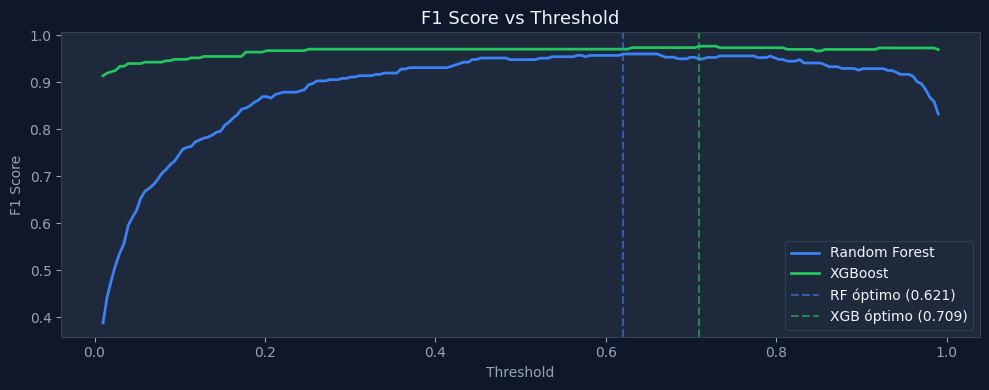

In [9]:
def find_optimal_threshold(probs, y_true):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_f1, best_t = 0, 0.5
    f1s = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        f1s.append(f1)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1, thresholds, f1s

rf_t,  rf_best_f1,  thresholds, rf_f1s  = find_optimal_threshold(rf_probs,  y_test)
xgb_t, xgb_best_f1, _,          xgb_f1s = find_optimal_threshold(xgb_probs, y_test)

print(f'RF  — Umbral óptimo: {rf_t:.4f}  | F1 máximo: {rf_best_f1:.4f}')
print(f'XGB — Umbral óptimo: {xgb_t:.4f} | F1 máximo: {xgb_best_f1:.4f}')

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0F172A')
ax.plot(thresholds, rf_f1s,  color=AZUL,  label='Random Forest', linewidth=2)
ax.plot(thresholds, xgb_f1s, color=VERDE, label='XGBoost',       linewidth=2)
ax.axvline(rf_t,  color=AZUL,  linestyle='--', alpha=0.6, label=f'RF óptimo ({rf_t:.3f})')
ax.axvline(xgb_t, color=VERDE, linestyle='--', alpha=0.6, label=f'XGB óptimo ({xgb_t:.3f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Threshold', color='#F1F5F9', fontsize=13)
ax.legend(facecolor='#1E293B', edgecolor='#334155')
plt.tight_layout()
plt.show()

## 6. Métricas y comparación de modelos

Reportamos múltiples métricas porque ninguna sola cuenta toda la historia:

- **Precision**: de las transacciones que marcamos como fraude, ¿cuántas realmente lo son? Afecta la carga operativa de revisión manual.
- **Recall**: de todos los fraudes reales, ¿cuántos detectamos? Afecta directamente las pérdidas no recuperadas.
- **F1**: media armónica de las dos anteriores; útil como número único para comparar modelos.
- **AUC-ROC**: mide la capacidad discriminante del modelo independientemente del umbral. Complementa F1 cuando el umbral puede variar en producción.
- **PR-AUC**: más informativo que ROC en datasets muy desbalanceados porque se enfoca en la clase positiva.

In [10]:
rf_preds  = (rf_probs  >= rf_t).astype(int)
xgb_preds = (xgb_probs >= xgb_t).astype(int)

def get_metrics(probs, preds, y_true, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        'Modelo': model_name,
        'Precision': round(precision_score(y_true, preds, zero_division=0), 4),
        'Recall': round(recall_score(y_true, preds, zero_division=0), 4),
        'F1': round(f1_score(y_true, preds, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_true, probs), 4),
        'PR-AUC': round(average_precision_score(y_true, probs), 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

rf_m  = get_metrics(rf_probs,  rf_preds,  y_test, 'RandomForest')
xgb_m = get_metrics(xgb_probs, xgb_preds, y_test, 'XGBoost')

metrics_df = pd.DataFrame([rf_m, xgb_m]).set_index('Modelo')
print('=== COMPARATIVA DE MÉTRICAS ===')
print(metrics_df[['Precision','Recall','F1','AUC-ROC','PR-AUC']].to_string())
print('\n⚠️  Nota: NO usamos Accuracy — con 1.5% fraude, predecir siempre legítimo da 98.5% de accuracy')

=== COMPARATIVA DE MÉTRICAS ===
              Precision  Recall      F1  AUC-ROC  PR-AUC
Modelo                                                  
RandomForest     0.9481  0.9733  0.9605   0.9999  0.9936
XGBoost          0.9613  0.9933  0.9770   0.9997  0.9942

⚠️  Nota: NO usamos Accuracy — con 1.5% fraude, predecir siempre legítimo da 98.5% de accuracy


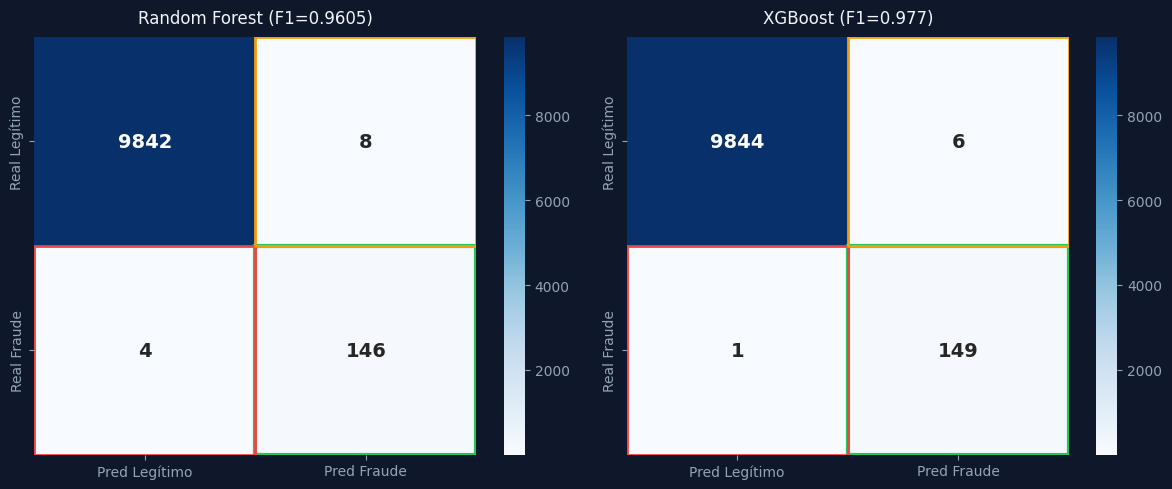

🟢 TP = fraudes correctamente detectados
🔴 FN = fraudes que escaparon (crítico para el negocio)
🟡 FP = legítimos bloqueados (costo operativo)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#0F172A')

def plot_cm(ax, cm_vals, title):
    tn, fp, fn, tp = cm_vals
    cm_arr = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legítimo','Pred Fraude'],
                yticklabels=['Real Legítimo','Real Fraude'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, color='#F1F5F9', fontsize=12, pad=10)
    # Colorear celda TP en verde, FN/FP en rojo
    ax.add_patch(plt.Rectangle((1,1), 1, 1, fill=False, edgecolor=VERDE, lw=3))
    ax.add_patch(plt.Rectangle((0,1), 1, 1, fill=False, edgecolor=ROJO,  lw=2))
    ax.add_patch(plt.Rectangle((1,0), 1, 1, fill=False, edgecolor=AMBER, lw=2))

plot_cm(axes[0], (rf_m['TN'],rf_m['FP'],rf_m['FN'],rf_m['TP']), f'Random Forest (F1={rf_m["F1"]})')
plot_cm(axes[1], (xgb_m['TN'],xgb_m['FP'],xgb_m['FN'],xgb_m['TP']), f'XGBoost (F1={xgb_m["F1"]})')

plt.tight_layout()
plt.show()
print(f'🟢 TP = fraudes correctamente detectados')
print(f'🔴 FN = fraudes que escaparon (crítico para el negocio)')
print(f'🟡 FP = legítimos bloqueados (costo operativo)')

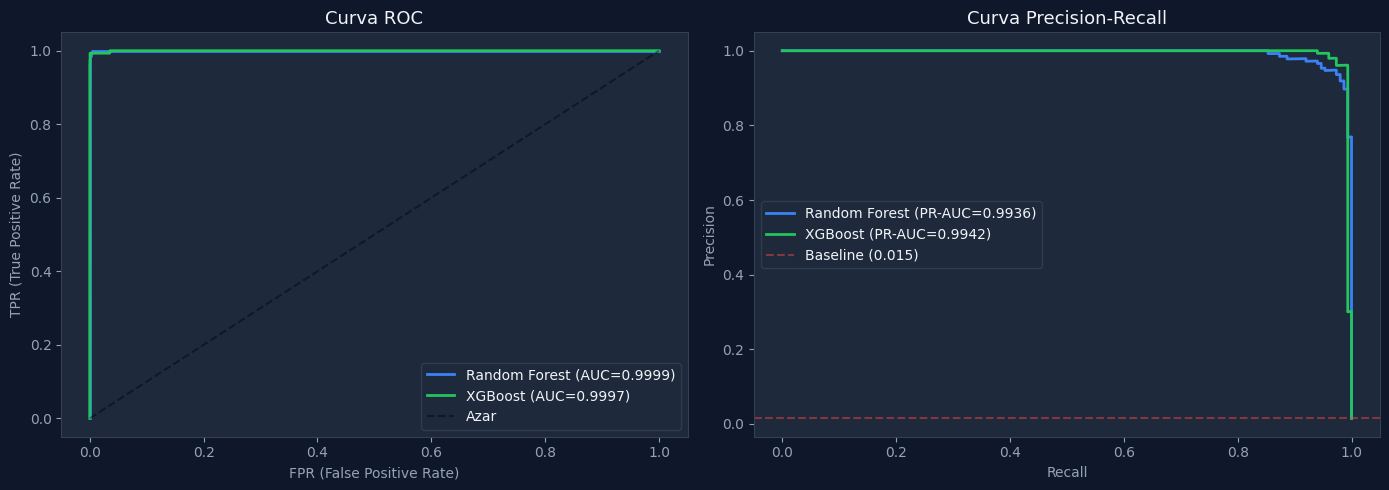

💡 PR-AUC es más informativa que ROC-AUC con clases muy desbalanceadas


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0F172A')

# Curva ROC
for probs, name, color in [(rf_probs,'Random Forest',AZUL),(xgb_probs,'XGBoost',VERDE)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Azar')
axes[0].set_xlabel('FPR (False Positive Rate)')
axes[0].set_ylabel('TPR (True Positive Rate)')
axes[0].set_title('Curva ROC', color='#F1F5F9', fontsize=13)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155')

# Curva Precision-Recall
for probs, name, color in [(rf_probs,'Random Forest',AZUL),(xgb_probs,'XGBoost',VERDE)]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{name} (PR-AUC={pr_auc:.4f})')
axes[1].axhline(y_test.mean(), color='#EF4444', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', color='#F1F5F9', fontsize=13)
axes[1].legend(facecolor='#1E293B', edgecolor='#334155')

plt.tight_layout()
plt.show()
print('💡 PR-AUC es más informativa que ROC-AUC con clases muy desbalanceadas')

## 7. Feature importance

La importancia de variables del Random Forest mide cuánto contribuye cada feature a la reducción de impureza en los árboles. Es una primera lectura útil pero tiene un sesgo conocido: variables continuas con muchos valores posibles tienden a aparecer más importantes simplemente porque ofrecen más puntos de corte. Por eso complementamos con SHAP en la siguiente sección.

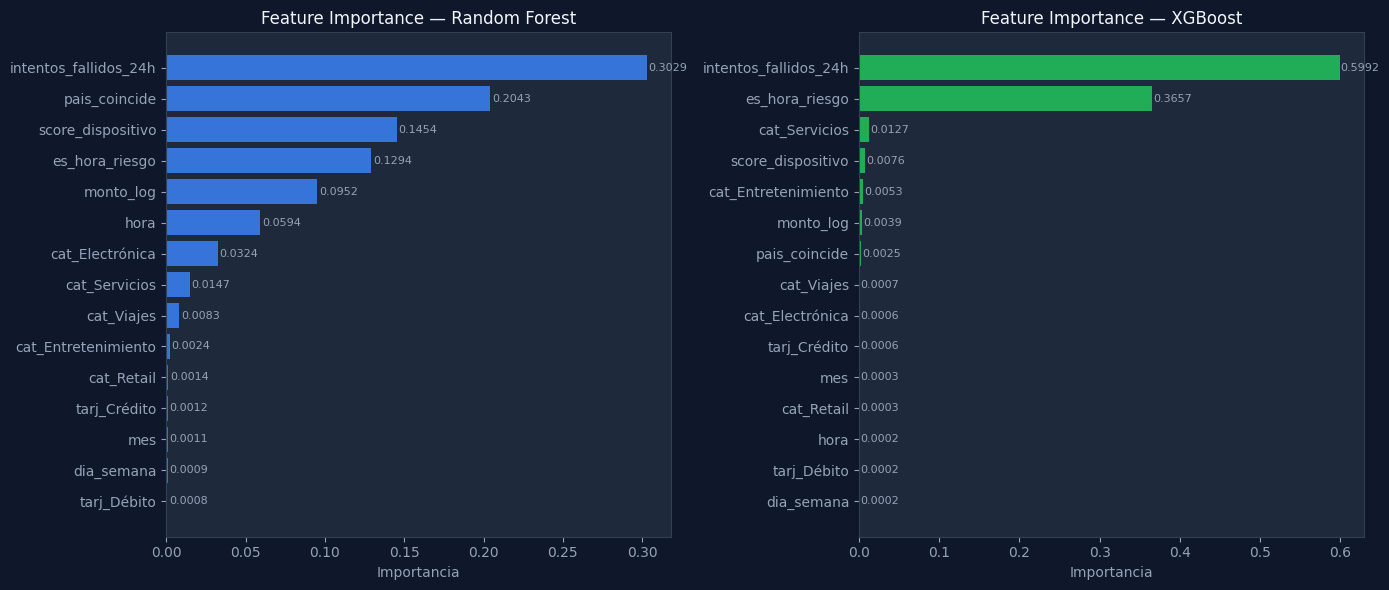

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0F172A')

for ax, model, name, color in [(axes[0],rf,'Random Forest',AZUL),(axes[1],xgb,'XGBoost',VERDE)]:
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp = imp.nlargest(15).sort_values()
    ax.barh(imp.index, imp.values, color=color, alpha=0.85)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Feature Importance — {name}', color='#F1F5F9', fontsize=12)
    for i, v in enumerate(imp.values):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, color='#94A3B8')

plt.tight_layout()
plt.show()

## 8. SHAP — Explicabilidad del modelo XGBoost

SHAP (SHapley Additive exPlanations) asigna a cada variable un valor que indica cuánto contribuyó a la predicción de fraude para cada transacción específica. A diferencia de la importancia global del RF, SHAP muestra la dirección del efecto (si la variable empuja hacia fraude o hacia legítimo) y es consistente a nivel de instancia.

Usamos TreeExplainer porque es exacto para modelos basados en árboles (no una aproximación) y es significativamente más rápido que el explicador general. El beeswarm plot ordena las variables por impacto promedio absoluto y muestra la distribución completa de efectos, no solo el promedio.

In [14]:
print('Calculando SHAP values (muestra de 2000 del test)...')
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values_raw = explainer.shap_values(X_test_sample)

# Compatibilidad con distintas versiones de SHAP
if hasattr(shap_values_raw, 'ndim') and shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]
elif isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw

print('✅ SHAP values calculados')

Calculando SHAP values (muestra de 2000 del test)...
✅ SHAP values calculados


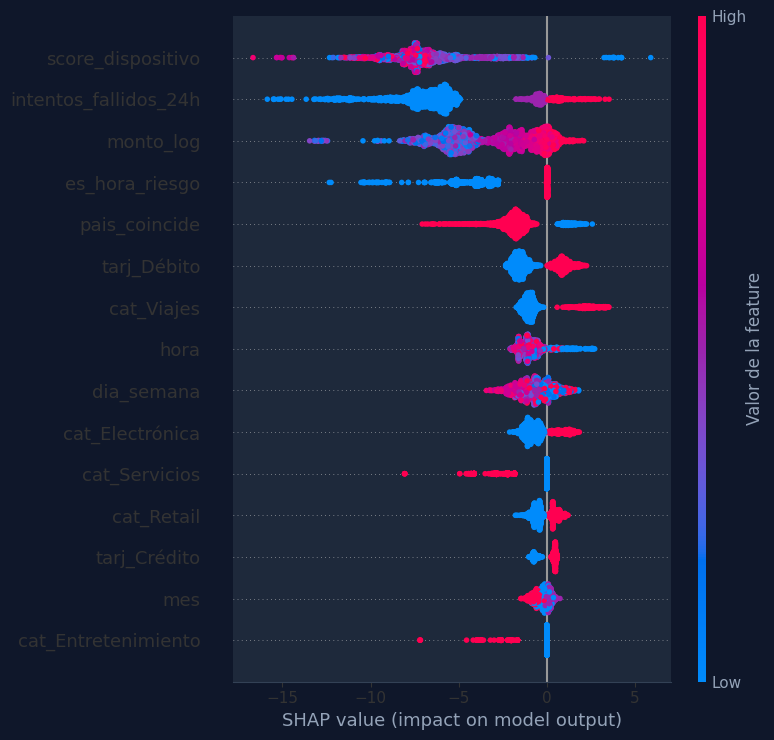

In [15]:
# Beeswarm plot (resumen global)
shap.summary_plot(shap_vals, X_test_sample, plot_type='dot', max_display=15,
                  show=True, color_bar_label='Valor de la feature')

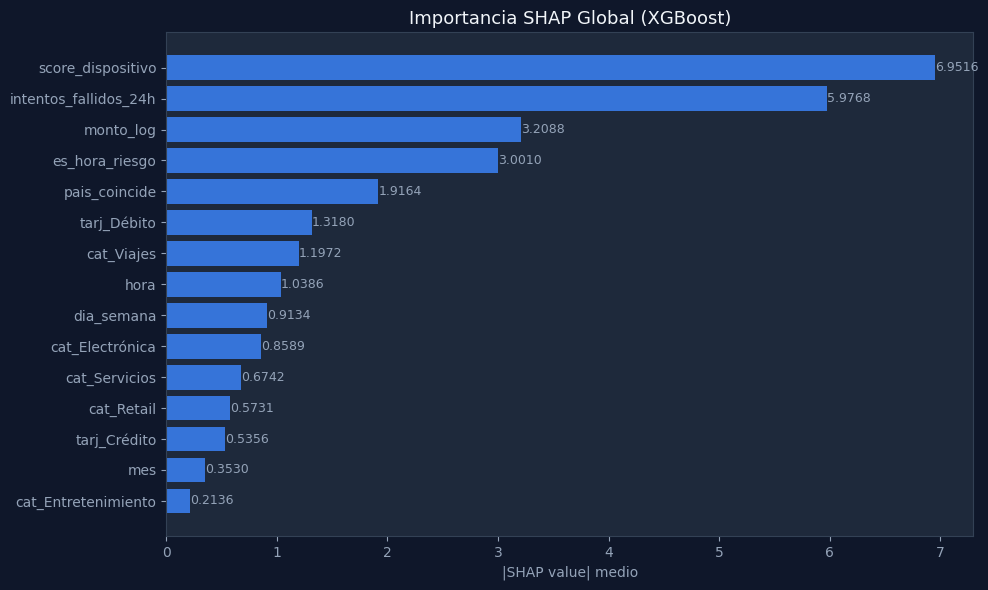

In [16]:
# Bar plot (importancia media absoluta SHAP)
shap_mean_abs = np.abs(shap_vals).mean(axis=0)
shap_imp = pd.Series(shap_mean_abs, index=X.columns).nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0F172A')
ax.barh(shap_imp.index, shap_imp.values, color=AZUL, alpha=0.85)
ax.set_xlabel('|SHAP value| medio')
ax.set_title('Importancia SHAP Global (XGBoost)', color='#F1F5F9', fontsize=13)
for i, v in enumerate(shap_imp.values):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9, color='#94A3B8')
plt.tight_layout()
plt.show()

=== EJEMPLO: TRANSACCIÓN FRAUDULENTA ===


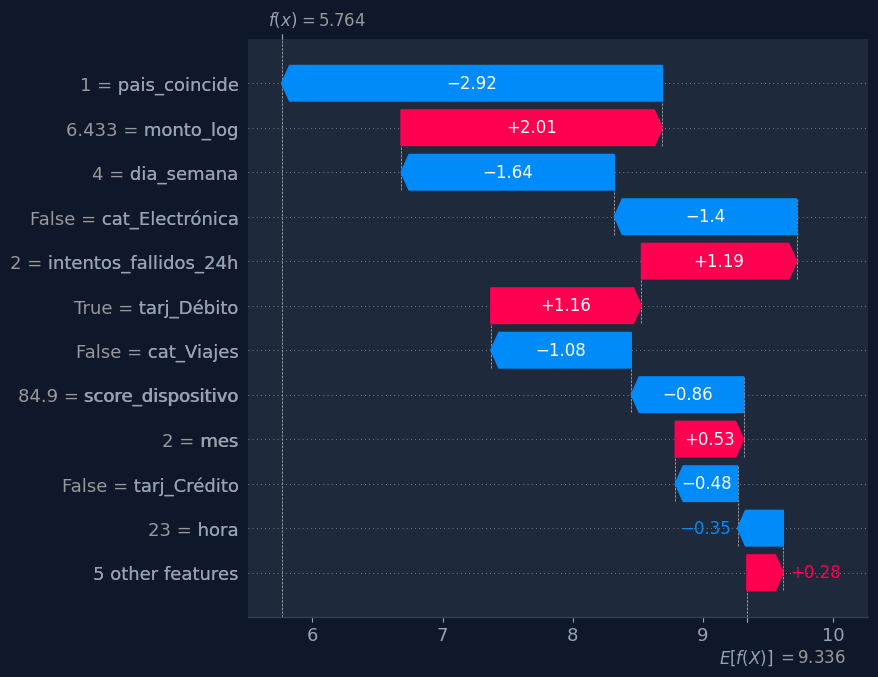

In [17]:
# Waterfall plot para una transacción fraudulenta
fraude_idx = np.where(y_test_sample.values == 1)[0]
legit_idx  = np.where(y_test_sample.values == 0)[0]

print('=== EJEMPLO: TRANSACCIÓN FRAUDULENTA ===')
expected = explainer.expected_value
if isinstance(expected, list): expected = expected[1]
if hasattr(expected, '__len__') and len(expected) > 1: expected = expected[1]

shap_exp = shap.Explanation(
    values=shap_vals[fraude_idx[0]],
    base_values=float(expected),
    data=X_test_sample.iloc[fraude_idx[0]].values,
    feature_names=X.columns.tolist()
)
shap.plots.waterfall(shap_exp, max_display=12, show=True)

=== EJEMPLO: TRANSACCIÓN LEGÍTIMA ===


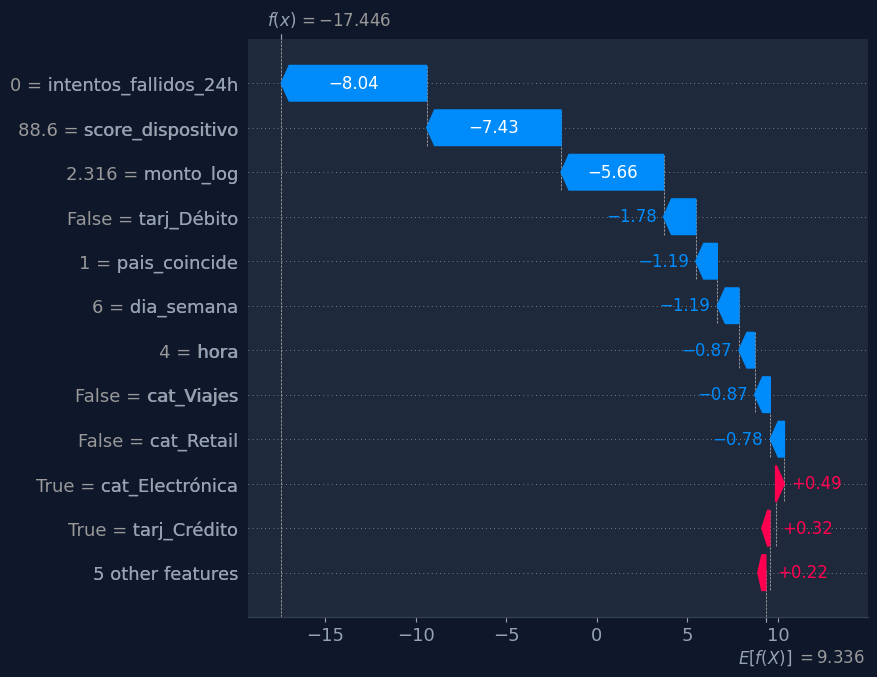

In [18]:
print('=== EJEMPLO: TRANSACCIÓN LEGÍTIMA ===')
shap_exp_legit = shap.Explanation(
    values=shap_vals[legit_idx[0]],
    base_values=float(expected),
    data=X_test_sample.iloc[legit_idx[0]].values,
    feature_names=X.columns.tolist()
)
shap.plots.waterfall(shap_exp_legit, max_display=12, show=True)

## 9. Análisis de negocio: costo real de cada tipo de error

Las métricas estadísticas son necesarias pero no suficientes para tomar decisiones operativas. Necesitamos traducir FP y FN a euros/dólares perdidos.

Un falso negativo (fraude que pasó) cuesta el monto completo de la transacción más costos de gestión. Un falso positivo (transacción legítima bloqueada) cuesta la pérdida de esa venta más el costo de atención al cliente y posible churn. Con estos números, el threshold óptimo estadístico puede no coincidir con el threshold óptimo de negocio — esta sección lo cuantifica.

In [19]:
# Costo de cada tipo de error
montos_fraude_test = np.expm1(X_test.iloc[np.where(y_test.values==1)[0]]['monto_log'])
MONTO_PROM_FRAUDE = montos_fraude_test.mean()
COSTO_FP = 5.0  # USD por revisión manual de falsa alarma

print(f'💰 Monto promedio de fraude en test: ${MONTO_PROM_FRAUDE:.2f}')
print(f'💰 Costo por FP (revisión manual): ${COSTO_FP}')

total_fraudes_test = y_test.sum()

for name, m in [('Random Forest', rf_m), ('XGBoost', xgb_m)]:
    costo_fn = m['FN'] * MONTO_PROM_FRAUDE
    costo_fp = m['FP'] * COSTO_FP
    costo_total = costo_fn + costo_fp
    sin_modelo  = total_fraudes_test * MONTO_PROM_FRAUDE
    ahorro      = sin_modelo - costo_total
    print(f'\n=== {name} ===')
    print(f'  FN (fraudes escapados):      {m["FN"]} → ${costo_fn:,.2f}')
    print(f'  FP (revisiones innecesarias):{m["FP"]} → ${costo_fp:,.2f}')
    print(f'  Costo total con modelo:      ${costo_total:,.2f}')
    print(f'  Sin modelo (0% detección):   ${sin_modelo:,.2f}')
    print(f'  💚 Ahorro neto:              ${ahorro:,.2f}')

💰 Monto promedio de fraude en test: $369.62
💰 Costo por FP (revisión manual): $5.0

=== Random Forest ===
  FN (fraudes escapados):      4 → $1,478.48
  FP (revisiones innecesarias):8 → $40.00
  Costo total con modelo:      $1,518.48
  Sin modelo (0% detección):   $55,443.00
  💚 Ahorro neto:              $53,924.52

=== XGBoost ===
  FN (fraudes escapados):      1 → $369.62
  FP (revisiones innecesarias):6 → $30.00
  Costo total con modelo:      $399.62
  Sin modelo (0% detección):   $55,443.00
  💚 Ahorro neto:              $55,043.38


NameError: name 'mticker' is not defined

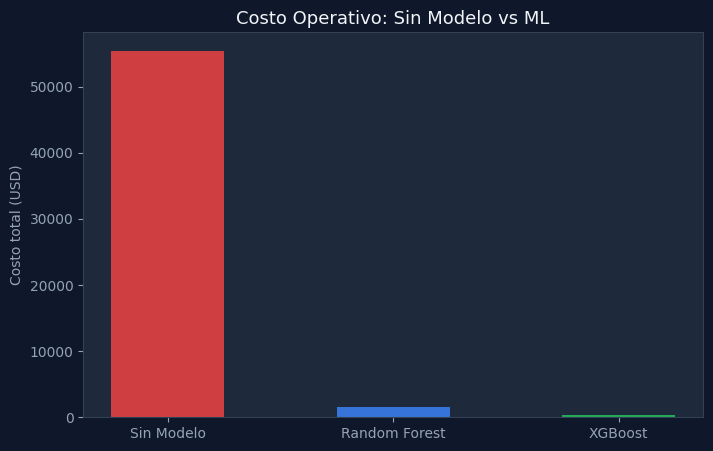

In [20]:
modelos   = ['Sin Modelo', 'Random Forest', 'XGBoost']
sin_model = total_fraudes_test * MONTO_PROM_FRAUDE
costos    = [
    sin_model,
    rf_m['FN']*MONTO_PROM_FRAUDE + rf_m['FP']*COSTO_FP,
    xgb_m['FN']*MONTO_PROM_FRAUDE + xgb_m['FP']*COSTO_FP,
]
colors_bar = [ROJO, AZUL, VERDE]

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0F172A')
bars = ax.bar(modelos, costos, color=colors_bar, alpha=0.85, width=0.5)
ax.set_ylabel('Costo total (USD)')
ax.set_title('Costo Operativo: Sin Modelo vs ML', color='#F1F5F9', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, costos):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()